In [1]:
# =========================
# Cell 1: Imports + config
# =========================
import os
import re
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Point this to your eval_results directory
directory_path = "runs/qwen35_9b_both_aug/eval_results/"

json_files = [
    f for f in glob.glob(os.path.join(directory_path, "*.json"))
    if os.path.basename(f) != "all_metrics.json"
]

print(f"Found {len(json_files)} result files")
for f in sorted(json_files)[:5]:
    print(" -", os.path.basename(f))

Found 3 result files
 - base_pretrained.json
 - checkpoint-436.json
 - checkpoint-872.json


In [2]:
# ==========================================
# Cell 2: Helpers to read the new file shape
# ==========================================
ALL_FIELDS = ["hazard_label", "hazard_present", "zone_relation", "object_state", "object_direction"]
FIELDS_BY_SUBSET = {
    "combined": ["hazard_label", "hazard_present", "zone_relation", "object_state", "object_direction"],
    "forklift": ["hazard_label", "hazard_present", "zone_relation", "object_state", "object_direction"],
    "robot": ["hazard_label", "hazard_present", "zone_relation", "object_state"],
}

def parse_step(filename: str) -> int:
    name = filename.lower()
    if "base" in name:
        return 0
    if "final" in name:
        return 999999

    m = re.search(r"checkpoint[-_]?(\d+)", name)
    if m:
        return int(m.group(1))

    m = re.search(r"[-_](\d+)\.json$", name)
    if m:
        return int(m.group(1))

    return -1

def safe_get(d, *keys, default=None):
    cur = d
    for k in keys:
        if not isinstance(cur, dict):
            return default
        cur = cur.get(k)
        if cur is None:
            return default
    return cur

def get_field_f1(subset_metrics, field):
    return safe_get(subset_metrics, "per_field_metrics", field, "macro_f1", default=np.nan)

def get_field_fp(subset_metrics, field):
    labels = safe_get(subset_metrics, "per_field_metrics", field, "labels", default={}) or {}
    return sum((info or {}).get("fp", 0) for info in labels.values())

def build_summary_row(file_path, content):
    filename = os.path.basename(file_path)
    metrics = content.get("metrics", {})
    row = {
        "checkpoint": filename.replace(".json", ""),
        "filename": filename,
        "step": parse_step(filename),
        "adapter_name": metrics.get("adapter_name"),
        "inference_time_sec": metrics.get("inference_time_sec", np.nan),
        "samples_per_sec": metrics.get("samples_per_sec", np.nan),
    }

    for subset in ["combined", "forklift", "robot"]:
        subset_metrics = safe_get(metrics, subset, default=None)
        if subset_metrics is None:
            subset_metrics = safe_get(metrics, "by_task", subset, default={}) or {}

        row[f"{subset}_total_samples"] = subset_metrics.get("total_samples", np.nan)
        row[f"{subset}_exact_match_accuracy"] = subset_metrics.get("exact_match_accuracy", np.nan)
        row[f"{subset}_relevant_field_accuracy"] = subset_metrics.get("relevant_field_accuracy", np.nan)
        row[f"{subset}_parse_failures"] = subset_metrics.get("parse_failures", np.nan)
        row[f"{subset}_gt_parse_failures"] = subset_metrics.get("ground_truth_parse_failures", np.nan)
        row[f"{subset}_hazard_f1"] = safe_get(subset_metrics, "hazard_present_binary", "f1", default=np.nan)
        row[f"{subset}_hazard_recall"] = safe_get(subset_metrics, "hazard_present_binary", "recall", default=np.nan)
        row[f"{subset}_hazard_precision"] = safe_get(subset_metrics, "hazard_present_binary", "precision", default=np.nan)

        for field in ALL_FIELDS:
            row[f"{subset}_{field}_acc"] = safe_get(subset_metrics, "per_field_accuracy", field, default=np.nan)
            row[f"{subset}_{field}_f1"] = get_field_f1(subset_metrics, field)
            row[f"{subset}_{field}_fp"] = get_field_fp(subset_metrics, field)

    return row

summary_rows = []

for file_path in json_files:
    with open(file_path, "r", encoding="utf-8") as f:
        content = json.load(f)
    summary_rows.append(build_summary_row(file_path, content))

summary_df = pd.DataFrame(summary_rows).sort_values(["step", "checkpoint"]).reset_index(drop=True)
summary_df.head()

,checkpoint,filename,step,adapter_name,inference_time_sec,samples_per_sec,combined_total_samples,combined_exact_match_accuracy,combined_relevant_field_accuracy,combined_parse_failures,...,robot_hazard_present_fp,robot_zone_relation_acc,robot_zone_relation_f1,robot_zone_relation_fp,robot_object_state_acc,robot_object_state_f1,robot_object_state_fp,robot_object_direction_acc,robot_object_direction_f1,robot_object_direction_fp
0,base_pretrained,base_pretrained.json,0,base_pretrained,4367.16,0.1743,761,0.1235,0.3209,0,...,537,0.0196,0.0136,550,0.4991,0.3594,281,NaN,NaN,0
1,checkpoint-436,checkpoint-436.json,436,checkpoint-436,3781.23,0.2013,761,0.8739,0.9202,0,...,24,0.9804,0.4950,11,0.9750,0.4937,14,NaN,NaN,0
2,checkpoint-872,checkpoint-872.json,872,checkpoint-872,3798.84,0.2003,761,0.9198,0.9414,0,...,18,0.9804,0.4950,11,0.9857,0.7964,8,NaN,NaN,0


In [3]:
# ==================================
# Cell 3: Quick summary table to use
# ==================================
core_cols = [
    "checkpoint", "step",
    "combined_exact_match_accuracy", "combined_relevant_field_accuracy", "combined_hazard_f1",
    "forklift_exact_match_accuracy", "forklift_relevant_field_accuracy", "forklift_hazard_f1",
    "robot_exact_match_accuracy", "robot_relevant_field_accuracy", "robot_hazard_f1",
    "samples_per_sec"
]

display(summary_df[core_cols].round(4))

,checkpoint,step,combined_exact_match_accuracy,combined_relevant_field_accuracy,combined_hazard_f1,forklift_exact_match_accuracy,forklift_relevant_field_accuracy,forklift_hazard_f1,robot_exact_match_accuracy,robot_relevant_field_accuracy,robot_hazard_f1,samples_per_sec
0,base_pretrained,0,0.1235,0.3209,0.0000,0.450,0.702,0.0000,0.0071,0.1511,0.0000,0.1743
1,checkpoint-436,436,0.8739,0.9202,0.9547,0.640,0.814,0.0000,0.9572,0.9675,0.9781,0.2013
2,checkpoint-872,872,0.9198,0.9414,0.9644,0.785,0.865,0.3125,0.9679,0.9755,0.9835,0.2003


In [4]:
from adjustText import adjust_text

# =======================================================
# Plot helpers with automatic label de-overlap
# =======================================================
def annotate_series(x_vals, y_vals, texts, fmt="{:.2f}", fontsize=8):
    for x, y in zip(x_vals, y_vals):
        if pd.isna(y):
            continue
        txt = plt.text(
            x, y, fmt.format(y),
            fontsize=fontsize,
            ha="center",
            va="bottom",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=0.2)
        )
        texts.append(txt)


def plot_metric_family(df, subset, metric_suffix, title=None, figsize=(14, 5)):
    valid_fields = []
    for field in FIELDS_BY_SUBSET[subset]:
        col = f"{subset}_{field}_{metric_suffix}"
        if col in df.columns and df[col].notna().any():
            valid_fields.append((field, col))

    if not valid_fields:
        print(f"No data to plot for {subset} / {metric_suffix}")
        return

    plt.figure(figsize=figsize)
    texts = []

    for field, col in valid_fields:
        label = field.replace("_", " ").title()
        plt.plot(df["checkpoint"], df[col], marker="o", linewidth=1.8, label=label)

        fmt = "{:.0f}" if metric_suffix == "fp" else "{:.2f}"
        annotate_series(df["checkpoint"], df[col], texts, fmt=fmt)

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
        only_move={"points": "y", "text": "y"},
        force_text=0.8,
        force_points=0.3
    )

    if title is None:
        title = f"{subset.title()} - {metric_suffix.upper()}"

    plt.title(title, fontsize=13, fontweight="bold")
    plt.xlabel("Checkpoint")
    plt.ylabel(metric_suffix.upper())
    plt.xticks(rotation=45, ha="right")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_overall_metrics(df, subset, figsize=(14, 5)):
    cols = [
        f"{subset}_exact_match_accuracy",
        f"{subset}_relevant_field_accuracy",
        f"{subset}_hazard_f1",
    ]
    labels = ["Exact Match", "Relevant Field Acc", "Hazard F1"]

    plt.figure(figsize=figsize)
    texts = []

    for col, label in zip(cols, labels):
        if col in df.columns and df[col].notna().any():
            plt.plot(df["checkpoint"], df[col], marker="o", linewidth=2, label=label)
            annotate_series(df["checkpoint"], df[col], texts, fmt="{:.2f}")

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
        only_move={"points": "y", "text": "y"},
        force_text=0.8,
        force_points=0.3
    )

    plt.title(f"{subset.title()} - Overall Scores", fontsize=13, fontweight="bold")
    plt.xlabel("Checkpoint")
    plt.ylabel("Score")
    plt.xticks(rotation=45, ha="right")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

0 [0.11047139 0.97364143]
3 [-0.58211871  0.96732818]
1 [ 0.97185052 -0.73316974]
4 [0.86203696 0.11392299]
10 [-0.25698261 -0.49204509]
2 [-0.20243084 -0.50252667]
5 [-0.29381004  0.30169492]
8 [-0.54542744  0.73108397]
11 [0.69415852 0.02188404]


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


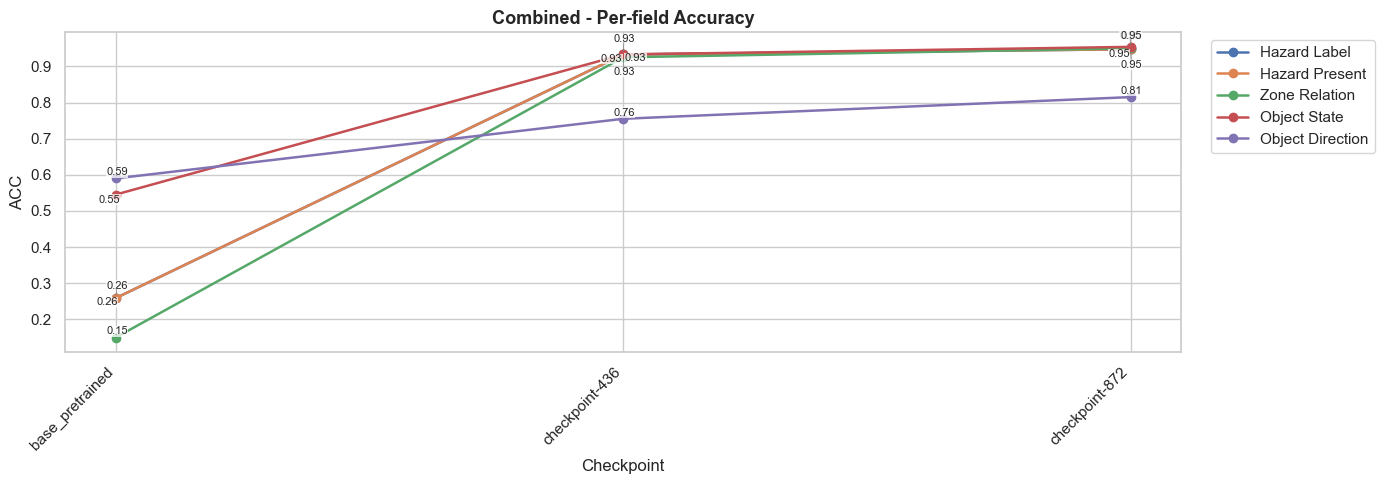

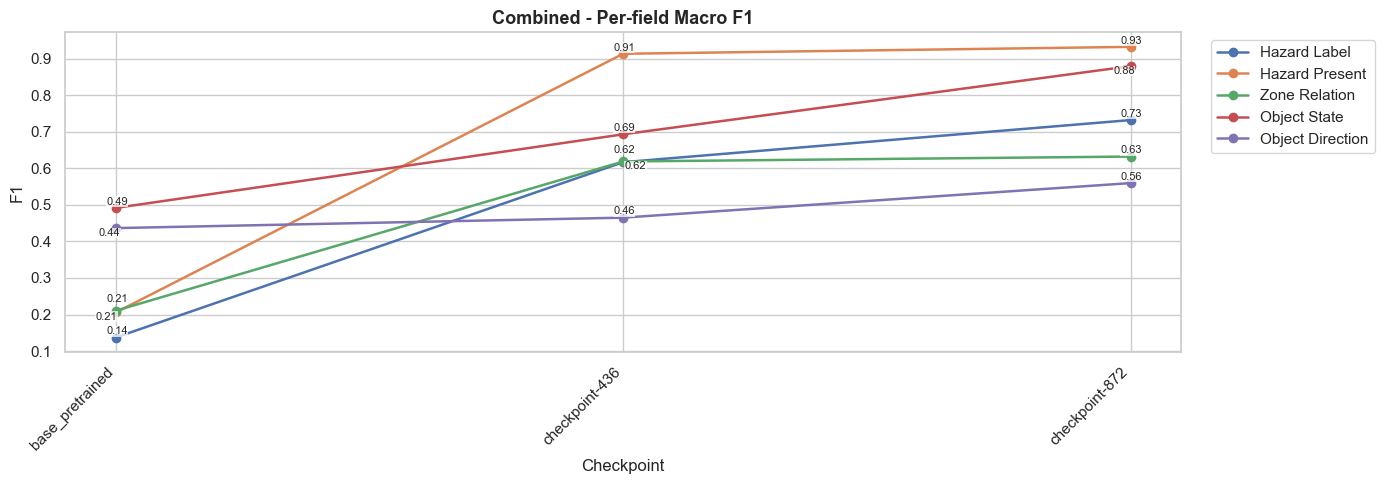

0 [0.21583724 0.97493516]
3 [-0.51822973 -0.90798888]
1 [ 0.18309053 -0.02993079]
4 [ 0.14780073 -0.76187665]
10 [0.97658388 0.57193756]
2 [ 0.31836685 -0.36289438]
5 [0.65377804 0.71833608]


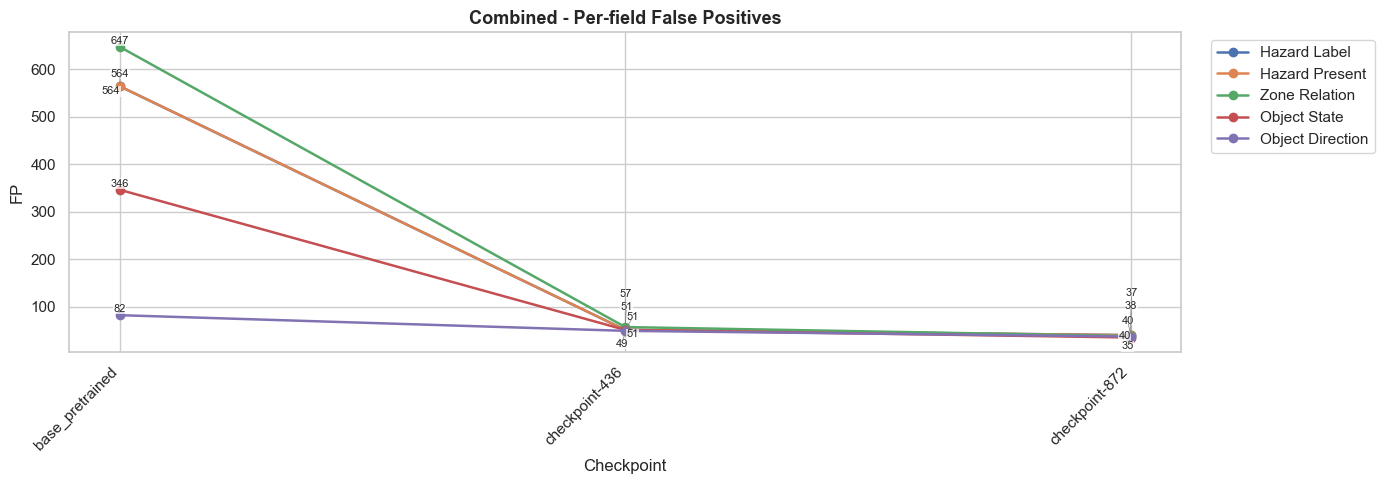

0 [ 0.68082327 -0.77974327]
3 [ 0.06001104 -0.0147324 ]
1 [0.22677116 0.26378825]
4 [ 0.10232262 -0.99740199]
8 [0.6455314  0.29242051]
11 [0.83757191 0.26868462]
2 [-0.75837967  0.56583295]
5 [ 0.41107452 -0.21756045]


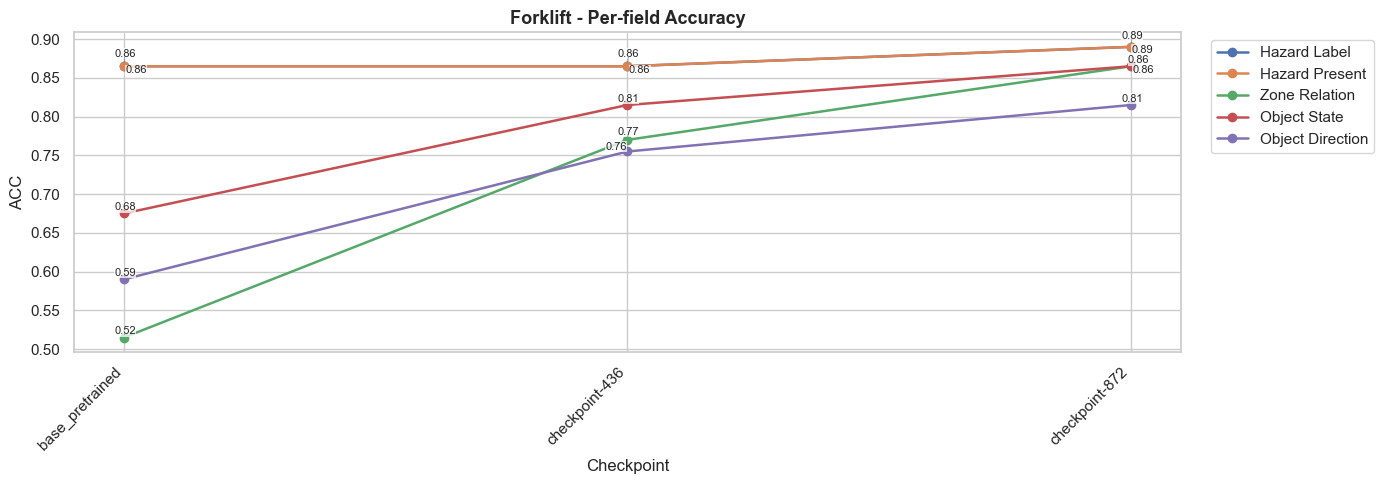

0 [-0.61083499  0.16745692]
3 [0.50716655 0.20519161]
1 [-0.73186985  0.10384954]
4 [-0.82833153  0.57360957]
2 [0.23852272 0.20225994]
5 [-0.41392847 -0.97894673]


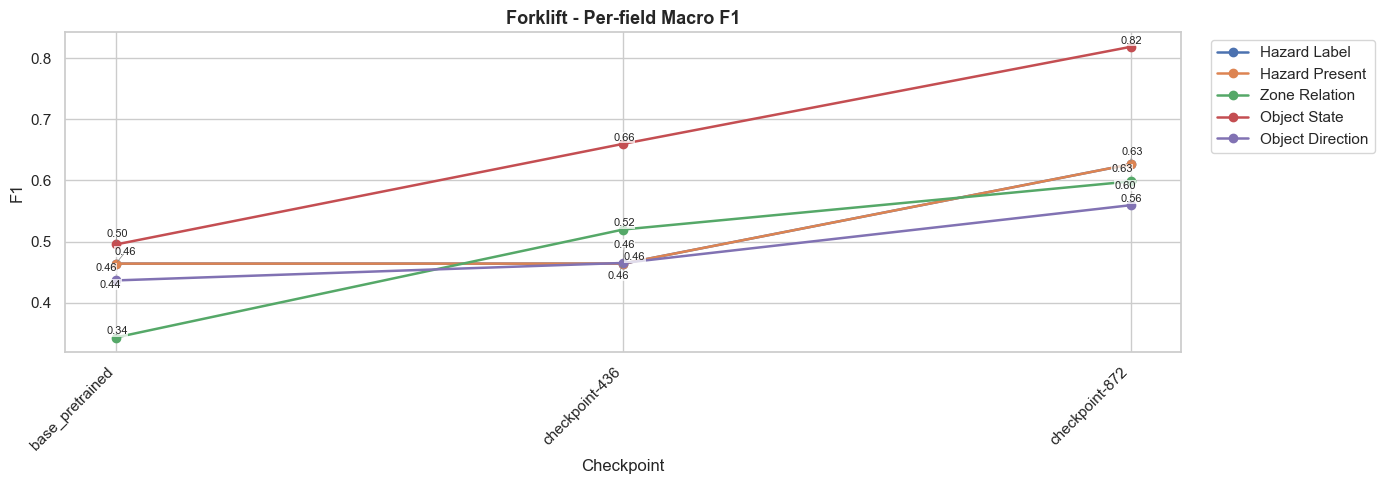

0 [0.74447739 0.23076364]
3 [ 0.68223752 -0.67404281]
1 [-0.84647832 -0.1295252 ]
4 [0.84632703 0.99339986]
2 [-0.72730783  0.71791173]
5 [ 0.52590628 -0.48171338]
8 [ 0.33339919 -0.63346214]
11 [-0.39250919 -0.81067774]


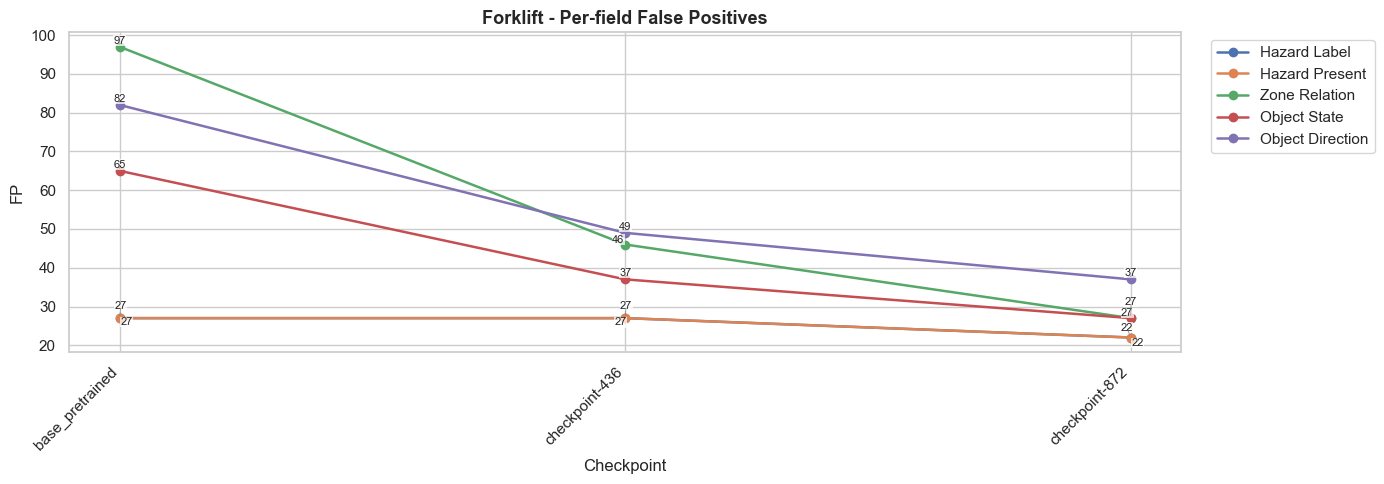

0 [-0.41327312 -0.0514828 ]
3 [-0.02642242  0.61350943]
1 [-0.92804505 -0.26287468]
4 [-0.95996292  0.18089324]
2 [-0.98227503  0.77675125]
5 [-0.63574672  0.04119051]
8 [ 0.24577325 -0.02558613]
11 [-0.89922298 -0.67323311]


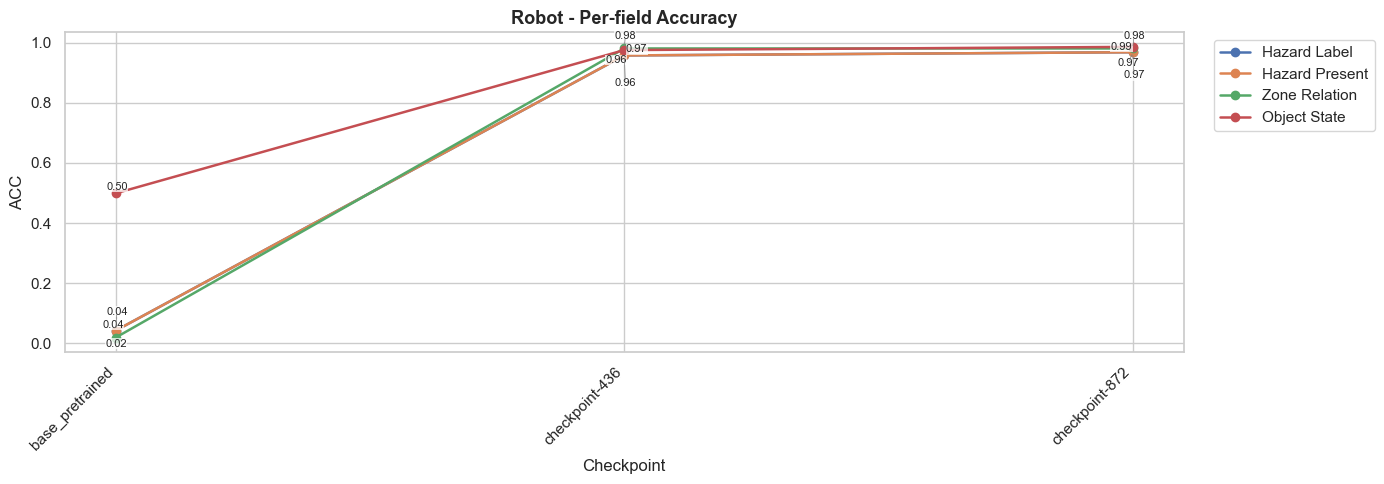

0 [-0.36540107  0.96252779]
3 [-0.89754409  0.83887265]
1 [ 0.12516401 -0.66133335]
4 [ 0.16679565 -0.22629811]
2 [-0.4272442  -0.72107724]
5 [-0.97731188 -0.22126177]


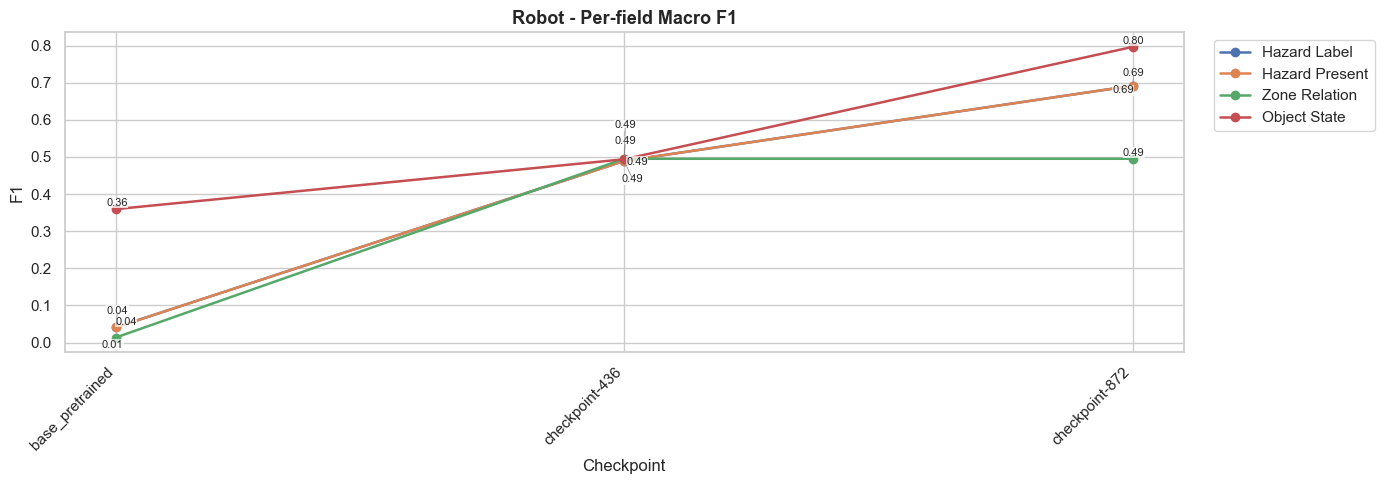

0 [ 0.60102599 -0.16507188]
3 [0.20407498 0.11471605]
1 [-0.49348078  0.3875557 ]
4 [-0.39310266 -0.04631435]
2 [ 0.64738097 -0.53427367]
5 [0.97974029 0.56545769]


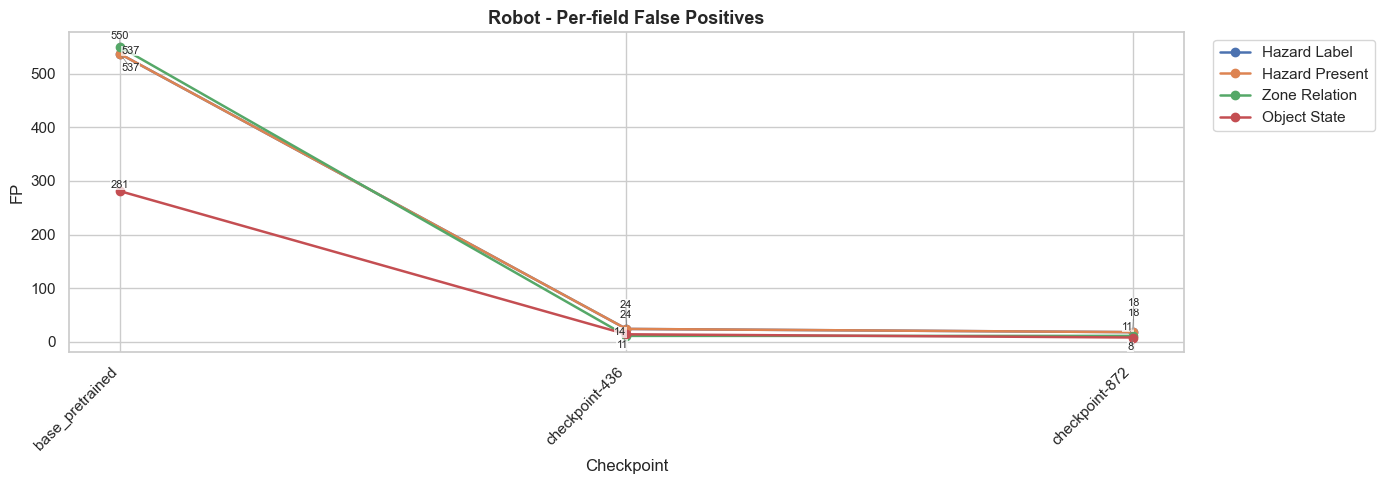

In [5]:
# ============================================
# Cell 6: Per-field ACC / F1 / FP for each set
# ============================================
plot_metric_family(summary_df, "combined", "acc", "Combined - Per-field Accuracy")
plot_metric_family(summary_df, "combined", "f1",  "Combined - Per-field Macro F1")
plot_metric_family(summary_df, "combined", "fp",  "Combined - Per-field False Positives")

plot_metric_family(summary_df, "forklift", "acc", "Forklift - Per-field Accuracy")
plot_metric_family(summary_df, "forklift", "f1",  "Forklift - Per-field Macro F1")
plot_metric_family(summary_df, "forklift", "fp",  "Forklift - Per-field False Positives")

plot_metric_family(summary_df, "robot", "acc", "Robot - Per-field Accuracy")
plot_metric_family(summary_df, "robot", "f1",  "Robot - Per-field Macro F1")
plot_metric_family(summary_df, "robot", "fp",  "Robot - Per-field False Positives")

In [6]:
# ===================================================
# Cell 7: Load per-sample rows from all result files
# ===================================================
sample_rows = []

for file_path in json_files:
    filename = os.path.basename(file_path)
    checkpoint = filename.replace(".json", "")
    step = parse_step(filename)

    with open(file_path, "r", encoding="utf-8") as f:
        content = json.load(f)

    per_sample = content.get("per_sample", [])
    for s in per_sample:
        gt = s.get("ground_truth") or {}
        pred = s.get("prediction_parsed") or {}
        meta = s.get("meta") or {}
        field_matches = s.get("field_matches") or {}

        row = {
            "checkpoint": checkpoint,
            "step": step,
            "sample_id": s.get("sample_id"),
            "task": s.get("task"),
            "exact_match": s.get("exact_match"),
            "ground_truth_parse_failed": s.get("ground_truth_parse_failed"),
            "inference_time_sec": s.get("inference_time_sec"),
            "hard_negative_bucket": s.get("hard_negative_bucket"),
            "prediction_raw": s.get("prediction_raw"),
            "ground_truth_text": s.get("ground_truth_text"),
            "source_video_id": meta.get("source_video_id"),
            "clip_start_sec": meta.get("clip_start_sec"),
            "clip_end_sec": meta.get("clip_end_sec"),
            "anchor_start_sec": meta.get("anchor_start_sec"),
            "anchor_end_sec": meta.get("anchor_end_sec"),
            "is_transition": meta.get("is_transition"),
            "is_ambiguous": meta.get("is_ambiguous"),
        }

        for field in ALL_FIELDS:
            row[f"gt_{field}"] = gt.get(field)
            row[f"pred_{field}"] = pred.get(field)
            row[f"match_{field}"] = field_matches.get(field)

        # True hazard false positive: GT says no, prediction says yes
        row["hazard_fp"] = (gt.get("hazard_present") == "no") and (pred.get("hazard_present") == "yes")

        # True hazard false negative: GT says yes, prediction says no
        row["hazard_fn"] = (gt.get("hazard_present") == "yes") and (pred.get("hazard_present") == "no")

        # Useful backup view: negative samples with any mistake
        row["negative_case_error"] = (gt.get("hazard_present") == "no") and (s.get("exact_match") is False)

        sample_rows.append(row)

samples_df = pd.DataFrame(sample_rows).sort_values(["step", "task", "sample_id"]).reset_index(drop=True)
samples_df.head()

,checkpoint,step,sample_id,task,exact_match,ground_truth_parse_failed,inference_time_sec,hard_negative_bucket,prediction_raw,ground_truth_text,...,match_zone_relation,gt_object_state,pred_object_state,match_object_state,gt_object_direction,pred_object_direction,match_object_direction,hazard_fp,hazard_fn,negative_case_error
0,base_pretrained,0,fork_금진Camera05_S20251213073941_E2025121307474...,forklift,False,False,6.3619,inside_stationary,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""no_hazard"", ""hazard_present""...",...,False,stationary,moving,False,none,towards,False,False,False,True
1,base_pretrained,0,fork_금진Camera05_S20251213073941_E2025121307474...,forklift,False,False,6.1667,inside_stationary,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""no_hazard"", ""hazard_present""...",...,False,stationary,moving,False,none,towards,False,False,False,True
2,base_pretrained,0,fork_금진Camera05_S20251213073941_E2025121307474...,forklift,False,False,6.3685,inside_stationary,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""no_hazard"", ""hazard_present""...",...,False,stationary,moving,False,none,towards,False,False,False,True
3,base_pretrained,0,fork_금진Camera05_S20251213073941_E2025121307474...,forklift,False,False,6.2085,inside_stationary,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""no_hazard"", ""hazard_present""...",...,False,stationary,moving,False,none,towards,False,False,False,True
4,base_pretrained,0,fork_금진Camera05_S20251213073941_E2025121307474...,forklift,False,False,6.1923,inside_stationary,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""no_hazard"", ""hazard_present""...",...,False,stationary,moving,False,none,towards,False,False,False,True


In [7]:
# ===========================================
# Cell 8: Count hazard FPs and FNs by run/task
# ===========================================
fp_fn_summary = (
    samples_df
    .groupby(["checkpoint", "task"], as_index=False)
    .agg(
        hazard_fp_count=("hazard_fp", "sum"),
        hazard_fn_count=("hazard_fn", "sum"),
        negative_case_error_count=("negative_case_error", "sum"),
        total_samples=("sample_id", "count"),
    )
    .sort_values(["checkpoint", "task"])
)

display(fp_fn_summary)

,checkpoint,task,hazard_fp_count,hazard_fn_count,negative_case_error_count,total_samples
0,base_pretrained,forklift,0,27,83,200
1,base_pretrained,robot,0,537,20,561
2,checkpoint-436,forklift,0,27,45,200
3,checkpoint-436,robot,24,0,24,561
4,checkpoint-872,forklift,0,22,21,200
5,checkpoint-872,robot,18,0,18,561


0 [ 0.6608955  -0.29945653]
3 [ 0.93065886 -0.09478623]


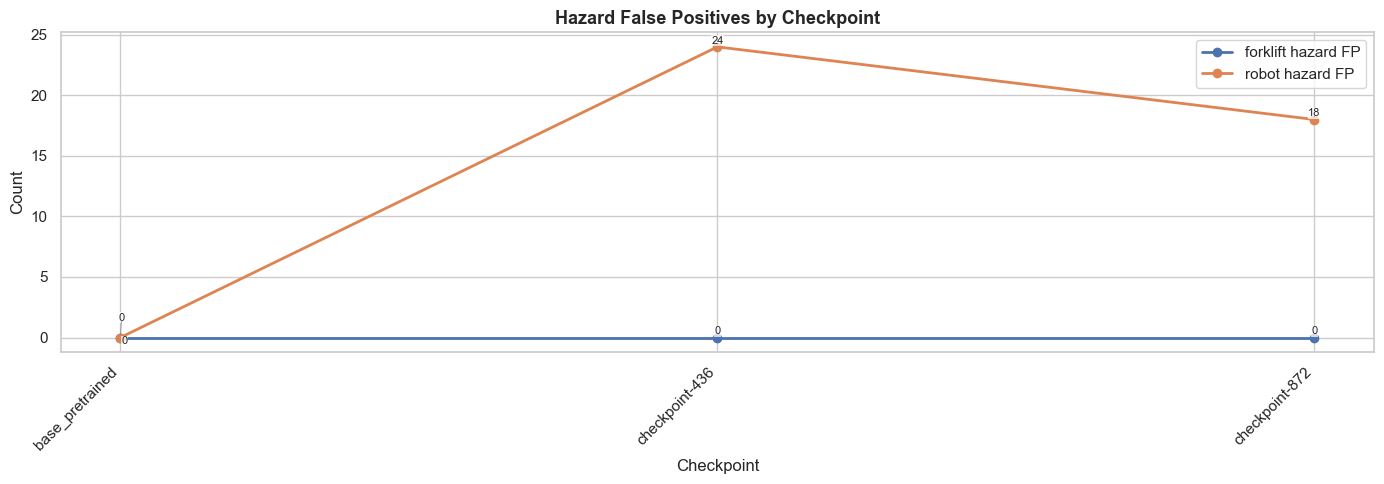

In [8]:
plt.figure(figsize=(14, 5))
texts = []

for task_name, sub_df in fp_fn_summary.groupby("task"):
    plt.plot(
        sub_df["checkpoint"],
        sub_df["hazard_fp_count"],
        marker="o",
        linewidth=2,
        label=f"{task_name} hazard FP"
    )
    annotate_series(sub_df["checkpoint"], sub_df["hazard_fp_count"], texts, fmt="{:.0f}")

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
    only_move={"points": "y", "text": "y"},
    force_text=0.8,
    force_points=0.3
)

plt.title("Hazard False Positives by Checkpoint", fontsize=13, fontweight="bold")
plt.xlabel("Checkpoint")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# Cell 8A: Ground-truth sample counts per label / per field
# ============================================================
count_rows = []

for _, row in samples_df.iterrows():
    task = row["task"]
    checkpoint = row["checkpoint"]

    for field in ALL_FIELDS:
        gt_col = f"gt_{field}"
        value = row.get(gt_col, None)

        # Skip robot object_direction since it is not a task field there
        if pd.isna(value) or value is None:
            continue

        count_rows.append({
            "checkpoint": checkpoint,
            "task": task,
            "field": field,
            "label": value,
            "count_type": "ground_truth"
        })

label_counts_df = (
    pd.DataFrame(count_rows)
    .groupby(["checkpoint", "task", "field", "label", "count_type"], as_index=False)
    .size()
    .rename(columns={"size": "num_samples"})
    .sort_values(["checkpoint", "task", "field", "label"])
)

display(label_counts_df.head(50))

,checkpoint,task,field,label,count_type,num_samples
0,base_pretrained,forklift,hazard_label,no_hazard,ground_truth,173
1,base_pretrained,forklift,hazard_label,unsafe_forklift_approach,ground_truth,27
2,base_pretrained,forklift,hazard_present,no,ground_truth,173
3,base_pretrained,forklift,hazard_present,yes,ground_truth,27
4,base_pretrained,forklift,object_direction,away,ground_truth,23
5,base_pretrained,forklift,object_direction,none,ground_truth,147
6,base_pretrained,forklift,object_direction,towards,ground_truth,30
7,base_pretrained,forklift,object_state,moving,ground_truth,53
8,base_pretrained,forklift,object_state,no_forklift,ground_truth,130
9,base_pretrained,forklift,object_state,stationary,ground_truth,17


In [19]:
# ============================================================
# Cell 8B: Prediction sample counts per label / per field
# ============================================================
pred_count_rows = []

for _, row in samples_df.iterrows():
    task = row["task"]
    checkpoint = row["checkpoint"]

    for field in ALL_FIELDS:
        pred_col = f"pred_{field}"
        value = row.get(pred_col, None)

        if pd.isna(value) or value is None:
            continue

        pred_count_rows.append({
            "checkpoint": checkpoint,
            "task": task,
            "field": field,
            "label": value,
            "count_type": "prediction"
        })

pred_label_counts_df = (
    pd.DataFrame(pred_count_rows)
    .groupby(["checkpoint", "task", "field", "label", "count_type"], as_index=False)
    .size()
    .rename(columns={"size": "num_samples"})
    .sort_values(["checkpoint", "task", "field", "label"])
)

# display(pred_label_counts_df.head(50))

In [20]:
# ============================================================
# Cell 8D: Easy pivot view
# ============================================================
selected_checkpoint = summary_df.iloc[-1]["checkpoint"]

label_counts_pivot = (
    all_label_counts_df[all_label_counts_df["checkpoint"] == selected_checkpoint]
    .pivot_table(
        index=["task", "field", "label"],
        columns="count_type",
        values="num_samples",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
    .sort_values(["task", "field", "label"])
)

print(f"Checkpoint: {selected_checkpoint}")
display(label_counts_pivot)

Checkpoint: checkpoint-872


count_type,task,field,label,ground_truth,prediction
0,forklift,hazard_label,no_hazard,173,195
1,forklift,hazard_label,unsafe_forklift_approach,27,5
2,forklift,hazard_present,no,173,195
3,forklift,hazard_present,yes,27,5
4,forklift,object_direction,away,23,24
5,forklift,object_direction,none,147,171
6,forklift,object_direction,towards,30,5
7,forklift,object_state,moving,53,29
8,forklift,object_state,no_forklift,130,152
9,forklift,object_state,stationary,17,19


In [15]:
# =======================================================
# Cell 10: Sample view for actual hazard false positives
# =======================================================
# Change this if you want a specific checkpoint
selected_checkpoint = summary_df.iloc[-1]["checkpoint"]

fp_cases = (
    samples_df[
        (samples_df["checkpoint"] == selected_checkpoint) &
        (samples_df["hazard_fp"])
    ][[
        "checkpoint", "task", "sample_id", "source_video_id",
        "clip_start_sec", "clip_end_sec",
        "gt_hazard_label", "pred_hazard_label",
        "gt_hazard_present", "pred_hazard_present",
        "gt_zone_relation", "pred_zone_relation",
        "gt_object_state", "pred_object_state",
        "gt_object_direction", "pred_object_direction",
        "hard_negative_bucket", "prediction_raw"
    ]]
    .sort_values(["task", "sample_id"])
)

print(f"Selected checkpoint: {selected_checkpoint}")
print(f"Number of hazard false positives: {len(fp_cases)}")
display(fp_cases.head(20))

Selected checkpoint: checkpoint-872
Number of hazard false positives: 18


,checkpoint,task,sample_id,source_video_id,clip_start_sec,clip_end_sec,gt_hazard_label,pred_hazard_label,gt_hazard_present,pred_hazard_present,gt_zone_relation,pred_zone_relation,gt_object_state,pred_object_state,gt_object_direction,pred_object_direction,hard_negative_bucket,prediction_raw
1722,checkpoint-872,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,0.0,5.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
1723,checkpoint-872,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,8.0,13.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
1724,checkpoint-872,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,16.0,21.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
1725,checkpoint-872,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,19.0,24.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
1726,checkpoint-872,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,32.0,37.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
1727,checkpoint-872,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,33.0,38.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
1728,checkpoint-872,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,40.0,45.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
1729,checkpoint-872,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,41.0,46.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
1730,checkpoint-872,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,42.0,47.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
1731,checkpoint-872,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,46.0,51.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."


In [16]:
# ====================================================================
# Cell 11: Backup sample view if hazard FP count is zero for a run
# ====================================================================
# This is useful for runs like "always predicts no hazard",
# where there may be zero hazard FPs but still many wrong negative cases.

negative_errors = (
    samples_df[
        (samples_df["checkpoint"] == selected_checkpoint) &
        (samples_df["negative_case_error"])
    ][[
        "checkpoint", "task", "sample_id", "source_video_id",
        "clip_start_sec", "clip_end_sec",
        "gt_hazard_label", "pred_hazard_label",
        "gt_hazard_present", "pred_hazard_present",
        "gt_zone_relation", "pred_zone_relation",
        "gt_object_state", "pred_object_state",
        "gt_object_direction", "pred_object_direction",
        "hard_negative_bucket", "prediction_raw"
    ]]
    .sort_values(["task", "sample_id"])
)

print(f"Selected checkpoint: {selected_checkpoint}")
print(f"Negative samples with any mistake: {len(negative_errors)}")
display(negative_errors.head(20))

Selected checkpoint: checkpoint-872
Negative samples with any mistake: 39


,checkpoint,task,sample_id,source_video_id,clip_start_sec,clip_end_sec,gt_hazard_label,pred_hazard_label,gt_hazard_present,pred_hazard_present,gt_zone_relation,pred_zone_relation,gt_object_state,pred_object_state,gt_object_direction,pred_object_direction,hard_negative_bucket,prediction_raw
1539,checkpoint-872,forklift,fork_금진Camera05_S20251213073941_E2025121307474...,fork_금진Camera05_S20251213073941_E20251213074740,144.0,149.0,no_hazard,no_hazard,no,no,outside,inside,moving,moving,away,away,other_no_hazard,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."
1559,checkpoint-872,forklift,fork_금진Camera05_S20251213073941_E2025121307474...,fork_금진Camera05_S20251213073941_E20251213074740,324.0,329.0,no_hazard,no_hazard,no,no,outside,no_forklift,moving,no_forklift,away,none,other_no_hazard,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."
1561,checkpoint-872,forklift,fork_금진Camera05_S20251213073941_E2025121307474...,fork_금진Camera05_S20251213073941_E20251213074740,357.0,362.0,no_hazard,no_hazard,no,no,outside,no_forklift,moving,no_forklift,away,none,other_no_hazard,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."
1567,checkpoint-872,forklift,fork_금진Camera05_S20251213073941_E2025121307474...,fork_금진Camera05_S20251213073941_E20251213074740,390.0,395.0,no_hazard,no_hazard,no,no,outside,inside,moving,moving,away,away,other_no_hazard,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."
1602,checkpoint-872,forklift,fork_금진Camera05_S20251213082156_E2025121308303...,fork_금진Camera05_S20251213082156_E20251213083037,37.0,42.0,no_hazard,no_hazard,no,no,no_forklift,inside,no_forklift,stationary,none,none,no_forklift,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."
1610,checkpoint-872,forklift,fork_금진Camera05_S20251213082156_E2025121308303...,fork_금진Camera05_S20251213082156_E20251213083037,163.0,168.0,no_hazard,no_hazard,no,no,outside,inside,moving,moving,away,away,other_no_hazard,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."
1615,checkpoint-872,forklift,fork_금진Camera05_S20251213082156_E2025121308303...,fork_금진Camera05_S20251213082156_E20251213083037,230.0,235.0,no_hazard,no_hazard,no,no,outside,no_forklift,moving,no_forklift,away,none,other_no_hazard,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."
1616,checkpoint-872,forklift,fork_금진Camera05_S20251213082156_E2025121308303...,fork_금진Camera05_S20251213082156_E20251213083037,232.0,237.0,no_hazard,no_hazard,no,no,outside,no_forklift,moving,no_forklift,away,none,other_no_hazard,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."
1617,checkpoint-872,forklift,fork_금진Camera05_S20251213082156_E2025121308303...,fork_금진Camera05_S20251213082156_E20251213083037,234.0,239.0,no_hazard,no_hazard,no,no,outside,no_forklift,moving,no_forklift,away,none,other_no_hazard,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."
1618,checkpoint-872,forklift,fork_금진Camera05_S20251213082156_E2025121308303...,fork_금진Camera05_S20251213082156_E20251213083037,241.0,246.0,no_hazard,no_hazard,no,no,outside,no_forklift,stationary,no_forklift,none,none,other_no_hazard,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."


In [17]:
# =========================================================
# Cell 12: Optional - inspect one specific sample in detail
# =========================================================
sample_to_inspect = None  # e.g. "fork_금진Camera05_S20251213073941_E20251213074740__000087000_000092000"

if sample_to_inspect:
    display(
        samples_df[samples_df["sample_id"] == sample_to_inspect].T
    )